# 13 — Proper Stacking (3-Model Version)

## What this notebook does
- Builds a **time-series-safe stacked ensemble** using **out-of-fold (OOF) probabilities**.
- Compares **two meta learners** on the same OOF meta-features:
  - `Meta_LogReg`
  - `Meta_HistGB`
- Saves only the **important compact outputs** needed for:
  - final comparison notebook
  - Streamlit dashboard deployment

## Base learners
- CatBoost
- LightGBM
- Logistic Regression



### Main metrics reported
The notebook computes several metrics internally, but the compact saved summaries focus on:
- `macro_recall`
- `recall_2`
- `precision_2`
- `ap_class2`
- `macro_map`
- `prob_rmse_macro`


In [1]:

from pathlib import Path
import json
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    average_precision_score,
    mean_squared_error,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

try:
    from catboost import CatBoostClassifier
except Exception as e:
    raise RuntimeError(
        "CatBoost is required for this notebook. Install it first with: pip install catboost\n"
        f"Original error: {e}"
    )

try:
    from lightgbm import LGBMClassifier
except Exception as e:
    raise RuntimeError(
        "LightGBM is required for this notebook. Install it first with: pip install lightgbm\n"
        f"Original error: {e}"
    )

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

OUT_CV_SUMMARY = MODEL_DIR / "stacking_3model_cv_summary.csv"
OUT_FINAL_RESULTS = MODEL_DIR / "stacking_3model_final_results.csv"
OUT_META_IMPORTANCE = MODEL_DIR / "stacking_3model_meta_importance.csv"
OUT_META_COMPARE = MODEL_DIR / "stacking_3model_meta_compare.csv"
OUT_DASHBOARD_FEATURES = MODEL_DIR / "stacking_3model_dashboard_features.csv"
OUT_DASHBOARD_BUNDLE = MODEL_DIR / "stacking_3model_dashboard_bundle.pkl"
OUT_MANIFEST = MODEL_DIR / "stacking_3model_manifest.json"

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Hold out the final test window.
TEST_START = pd.Timestamp("2025-07-01 00:00:00")

# Time-series CV setup:
# N_TIME_CHUNKS=4 -> 3 rolling validation folds on the development data.
N_TIME_CHUNKS = 4
MIN_TRAIN_CHUNKS = 1

# Lightweight model settings chosen to run on a MacBook Air more easily.
THREADS = min(6, os.cpu_count() or 4)
CB_ITER = 220
LGBM_EST = 220
LOGREG_MAX_ITER = 1200
HISTGB_EST = 220


print("Input dataset:", SUPERVISED_PATH)
print("Model output folder:", MODEL_DIR)


Input dataset: ../data/processed/supervised_hood_3h_multiclass.csv
Model output folder: ../models


In [2]:

# ------------------------------------------------------------
# Load the supervised panel dataset
# ------------------------------------------------------------
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)

if "time_3h" not in df.columns:
    raise ValueError("Expected a 'time_3h' column in supervised_hood_3h_multiclass.csv")
if "y_class" not in df.columns:
    raise ValueError("Expected a 'y_class' target column in supervised_hood_3h_multiclass.csv")

df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df = df.loc[df["time_3h"].notna()].copy()

# Keep neighbourhood codes as strings for stable categorical handling.
if "HOOD_158_CODE" in df.columns:
    df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)

df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce")
df = df.loc[df["y_class"].notna()].copy()
df["y_class"] = df["y_class"].astype("int8")

sort_cols = ["time_3h"] + (["HOOD_158_CODE"] if "HOOD_158_CODE" in df.columns else [])
df = df.sort_values(sort_cols).reset_index(drop=True)

print("Shape:", df.shape)
print("Date range:", df["time_3h"].min(), "to", df["time_3h"].max())
print("\nClass distribution (full dataset):")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))
display(df.head())


Shape: (1383922, 50)
Date range: 2023-01-02 00:00:00 to 2025-12-31 18:00:00

Class distribution (full dataset):
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


,HOOD_158_CODE,time_3h,collisions,injury_collisions,ftr_collisions,pd_collisions,pedestrian_collisions,bicycle_collisions,pressure_sea,wind_speed,...,visibility_lag_1,rain_lag_1,snow_lag_1,snow_on_ground_lag_1,wind_speed_lag_1,relative_humidity_lag_1,pressure_sea_lag_1,cloud_cover_8_lag_1,y_count_next,y_class
0,001,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0
1,002,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0
2,003,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0
3,004,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,1.0,1
4,005,2023-01-02,0,0,0,0,0,0,101.643,8.0,...,9700.0,8.4,0.0,0.0,11.333,100.0,101.577,7.333,0.0,0


In [3]:

# ------------------------------------------------------------
# Split into development and final test sets
# ------------------------------------------------------------
dev_mask = df["time_3h"] < TEST_START
test_mask = ~dev_mask

y = df["y_class"].copy()
drop_targets = [c for c in ["y_class", "y_count_next"] if c in df.columns]
X = df.drop(columns=drop_targets, errors="ignore").copy()

time_all = df["time_3h"].copy()
X = X.drop(columns=["time_3h"], errors="ignore")

X_dev = X.loc[dev_mask].reset_index(drop=True).copy()
y_dev = y.loc[dev_mask].reset_index(drop=True).copy()
time_dev = time_all.loc[dev_mask].reset_index(drop=True).copy()

X_test = X.loc[test_mask].reset_index(drop=True).copy()
y_test = y.loc[test_mask].reset_index(drop=True).copy()
time_test = time_all.loc[test_mask].reset_index(drop=True).copy()

if len(X_dev) == 0 or len(X_test) == 0:
    raise ValueError("Development or test split is empty. Check TEST_START against your data range.")

print("Dev shape:", X_dev.shape, "| Test shape:", X_test.shape)
print("Dev range:", time_dev.min(), "to", time_dev.max())
print("Test range:", time_test.min(), "to", time_test.max())
print("\nDev class distribution:")
print(y_dev.value_counts(normalize=True).sort_index().round(4))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(4))


Dev shape: (1151504, 47) | Test shape: (232418, 47)
Dev range: 2023-01-02 00:00:00 to 2025-06-30 21:00:00
Test range: 2025-07-01 00:00:00 to 2025-12-31 18:00:00

Dev class distribution:
y_class
0    0.8927
1    0.0930
2    0.0143
Name: proportion, dtype: float64

Test class distribution:
y_class
0    0.8942
1    0.0912
2    0.0147
Name: proportion, dtype: float64


In [4]:

# ------------------------------------------------------------
# Helper functions: preprocessing, models, folds, metrics, plots
# ------------------------------------------------------------
def make_ohe():
    """Create a OneHotEncoder that works across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# Treat string/object columns as categorical. Also keep HOOD_158_CODE categorical.
cat_cols = [c for c in X_dev.columns if X_dev[c].dtype == "object"]
if "HOOD_158_CODE" in X_dev.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

# Remove duplicates while preserving order.
cat_cols = list(dict.fromkeys(cat_cols))
num_cols = [c for c in X_dev.columns if c not in cat_cols]

for frame in [X_dev, X_test]:
    for c in cat_cols:
        frame[c] = frame[c].astype(str).fillna("missing")

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("Total features used:", X_dev.shape[1])

def build_preprocessor(use_scaler_for_num=False):
    """
    Build a preprocessing pipeline for sklearn-style models.
    - Numeric: median imputation (+ optional scaling)
    - Categorical: mode imputation + one-hot encoding
    """
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if use_scaler_for_num:
        num_steps.append(("scaler", StandardScaler()))

    num_pipe = Pipeline(num_steps)
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_ohe()),
    ])

    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop")

def build_logreg_pipe():
    return Pipeline([
        ("preprocess", build_preprocessor(use_scaler_for_num=True)),
        ("clf", LogisticRegression(
            max_iter=LOGREG_MAX_ITER,
            solver="lbfgs",
            multi_class="multinomial",
            class_weight="balanced",
            random_state=RANDOM_SEED,
        )),
    ])

def build_lgbm_pipe():
    return Pipeline([
        ("preprocess", build_preprocessor(use_scaler_for_num=False)),
        ("clf", LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=LGBM_EST,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=100,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_SEED,
            class_weight="balanced",
            n_jobs=THREADS,
            verbosity=-1,
        )),
    ])

def build_cb_model(y_fit):
    """
    CatBoost can consume raw columns directly.
    We use class weights derived from the current training fold.
    """
    class_counts = pd.Series(y_fit).value_counts().sort_index()
    weights = []
    for cls in [0, 1, 2]:
        count = max(1, int(class_counts.get(cls, 1)))
        weights.append(len(y_fit) / (3.0 * count))

    return CatBoostClassifier(
        loss_function="MultiClass",
        iterations=CB_ITER,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_SEED,
        verbose=False,
        thread_count=THREADS,
        class_weights=weights,
    )



def make_time_folds(time_series, n_chunks=N_TIME_CHUNKS, min_train_chunks=MIN_TRAIN_CHUNKS):
    """
    Split unique timestamps into contiguous chunks, then create rolling folds:
    train = all chunks before the validation chunk
    valid = current chunk
    """
    unique_times = np.array(sorted(pd.Series(time_series).astype("datetime64[ns]").unique()))
    if len(unique_times) < n_chunks:
        raise ValueError(f"Need at least {n_chunks} unique time points for {n_chunks} chunks, got {len(unique_times)}.")

    chunks = np.array_split(unique_times, n_chunks)
    folds = []

    for val_chunk_idx in range(min_train_chunks, len(chunks)):
        train_times = np.concatenate(chunks[:val_chunk_idx])
        val_times = chunks[val_chunk_idx]
        tr_idx = np.where(pd.Series(time_series).isin(train_times).values)[0]
        va_idx = np.where(pd.Series(time_series).isin(val_times).values)[0]

        if len(tr_idx) == 0 or len(va_idx) == 0:
            continue

        folds.append((tr_idx, va_idx))

    if len(folds) == 0:
        raise ValueError("No time-series folds were created. Check your timestamps and chunk settings.")
    return folds

def eval_multiclass(y_true, y_pred, proba, name="model", split="cv"):
    """
    Compute the main evaluation metrics used across this project.
    """
    y_true_arr = np.asarray(y_true)
    y_pred_arr = np.asarray(y_pred)
    proba_arr = np.asarray(proba)

    rec = recall_score(
        y_true_arr, y_pred_arr,
        labels=[0, 1, 2],
        average=None,
        zero_division=0,
    )
    macro_rec = float(np.mean(rec))

    prec2 = precision_score(
        (y_true_arr == 2).astype(int),
        (y_pred_arr == 2).astype(int),
        zero_division=0,
    )
    pred_class2_rate = float((y_pred_arr == 2).mean())

    # Average Precision for each class, then macro/weighted MAP summaries.
    ap_dict = {}
    ap_vals = []
    class_support = []

    for cls in [0, 1, 2]:
        y_true_bin = (y_true_arr == cls).astype(int)
        support = int(y_true_bin.sum())
        class_support.append(support)

        if support == 0:
            ap = np.nan
        else:
            ap = float(average_precision_score(y_true_bin, proba_arr[:, cls]))

        ap_dict[f"ap_class{cls}"] = ap
        if not np.isnan(ap):
            ap_vals.append(ap)

    macro_map = float(np.mean(ap_vals)) if len(ap_vals) else np.nan

    valid_pairs = [
        (ap_dict[f"ap_class{cls}"], class_support[cls])
        for cls in [0, 1, 2]
        if not np.isnan(ap_dict[f"ap_class{cls}"])
    ]
    if len(valid_pairs):
        weighted_map = float(
            np.average(
                [x[0] for x in valid_pairs],
                weights=[x[1] for x in valid_pairs],
            )
        )
    else:
        weighted_map = np.nan

    label_rmse = float(np.sqrt(mean_squared_error(y_true_arr, y_pred_arr)))

    y_onehot = np.zeros((len(y_true_arr), 3), dtype=float)
    y_onehot[np.arange(len(y_true_arr)), y_true_arr.astype(int)] = 1.0
    prob_rmse_macro = float(
        np.mean([
            np.sqrt(mean_squared_error(y_onehot[:, c], proba_arr[:, c]))
            for c in range(3)
        ])
    )

    row = {
        "split": split,
        "model": name,
        "macro_recall": macro_rec,
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "precision_2": float(prec2),
        "pred_class2_rate": pred_class2_rate,
        "macro_map": macro_map,
        "weighted_map": weighted_map,
        "label_rmse": label_rmse,
        "prob_rmse_macro": prob_rmse_macro,
    }
    row.update(ap_dict)
    return row

def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels([0, 1, 2])
    ax.set_yticklabels([0, 1, 2])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center")

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# Create rolling folds once and reuse them.
folds = make_time_folds(time_dev)
print("Number of folds:", len(folds))
for fold_num, (tr_idx, va_idx) in enumerate(folds, start=1):
    print(f"Fold {fold_num} -> train rows: {len(tr_idx)}, val rows: {len(va_idx)}")


Numeric columns: 46
Categorical columns: 1
Total features used: 47
Number of folds: 3
Fold 1 -> train rows: 287876, val rows: 287876
Fold 2 -> train rows: 575752, val rows: 287876
Fold 3 -> train rows: 863628, val rows: 287876


In [5]:

# ------------------------------------------------------------
# Base learner OOF training
# ------------------------------------------------------------
base_model_builders = {
    "CatBoost": build_cb_model,
    "LightGBM": build_lgbm_pipe,
    "LogReg": build_logreg_pipe,
}

n_dev = len(X_dev)
n_classes = 3

# OOF probability matrices: one per base learner.
oof_proba = {
    name: np.full((n_dev, n_classes), np.nan, dtype=float)
    for name in base_model_builders
}

# Track which rows are covered by validation folds and which fold each row belongs to.
coverage = np.zeros(n_dev, dtype=bool)
oof_fold_id = np.full(n_dev, -1, dtype=int)

fold_rows = []

for fold_num, (tr_idx, va_idx) in enumerate(folds, start=1):
    X_tr = X_dev.iloc[tr_idx].copy()
    y_tr = y_dev.iloc[tr_idx].copy()
    X_va = X_dev.iloc[va_idx].copy()
    y_va = y_dev.iloc[va_idx].copy()

    coverage[va_idx] = True
    oof_fold_id[va_idx] = fold_num

    print(f"\n===== Fold {fold_num} / {len(folds)} =====")
    print("Train shape:", X_tr.shape, "| Val shape:", X_va.shape)

    for model_name, builder in base_model_builders.items():
        print(f"Training {model_name} on fold {fold_num}...")

        if model_name == "CatBoost":
            model = builder(y_tr)
            # CatBoost accepts raw DataFrame columns and categorical column names.
            model.fit(X_tr, y_tr, cat_features=cat_cols)
            proba_va = model.predict_proba(X_va)
        else:
            model = builder()
            model.fit(X_tr, y_tr)
            proba_va = model.predict_proba(X_va)

        pred_va = np.asarray(proba_va).argmax(axis=1)
        oof_proba[model_name][va_idx] = proba_va

        row = eval_multiclass(y_va, pred_va, proba_va, name=model_name, split=f"fold_{fold_num}")
        row["fold"] = fold_num
        fold_rows.append(row)

fold_df = pd.DataFrame(fold_rows)
display(fold_df)

# Compact CV summary for base learners.
cv_summary = (
    fold_df.groupby("model", as_index=False)[
        [
            "macro_recall",
            "recall_2",
            "precision_2",
            "ap_class2",
            "macro_map",
            "prob_rmse_macro",
        ]
    ]
    .mean()
    .sort_values(["macro_recall", "ap_class2", "prob_rmse_macro"], ascending=[False, False, True])
    .reset_index(drop=True)
)
display(cv_summary)

covered_idx = np.where(coverage)[0]
if len(covered_idx) == 0:
    raise ValueError("No OOF-covered rows were produced. Check fold creation.")

# Build the meta-feature matrix: [model1_p0, model1_p1, model1_p2, model2_p0, ...]
meta_parts = []
meta_feature_names = []
for model_name in base_model_builders:
    meta_parts.append(oof_proba[model_name][covered_idx])
    meta_feature_names.extend([f"{model_name}_p0", f"{model_name}_p1", f"{model_name}_p2"])

X_meta_train = np.hstack(meta_parts)
y_meta_train = y_dev.iloc[covered_idx].to_numpy()
meta_fold_ids = oof_fold_id[covered_idx]

print("\nMeta-train matrix shape:", X_meta_train.shape)
print("Unique meta fold IDs:", np.unique(meta_fold_ids))



===== Fold 1 / 3 =====
Train shape: (287876, 47) | Val shape: (287876, 47)
Training CatBoost on fold 1...
Training LightGBM on fold 1...
Training LogReg on fold 1...

===== Fold 2 / 3 =====
Train shape: (575752, 47) | Val shape: (287876, 47)
Training CatBoost on fold 2...
Training LightGBM on fold 2...
Training LogReg on fold 2...

===== Fold 3 / 3 =====
Train shape: (863628, 47) | Val shape: (287876, 47)
Training CatBoost on fold 3...
Training LightGBM on fold 3...
Training LogReg on fold 3...


,split,model,macro_recall,recall_0,recall_1,recall_2,precision_2,pred_class2_rate,macro_map,weighted_map,label_rmse,prob_rmse_macro,ap_class0,ap_class1,ap_class2,fold
0,fold_1,CatBoost,0.536189,0.675427,0.351300,0.581840,0.073044,0.115800,0.399145,0.867350,0.774082,0.377902,0.956401,0.129825,0.111208,1
1,fold_1,LightGBM,0.529543,0.678595,0.370488,0.539546,0.068886,0.113865,0.400938,0.868555,0.773386,0.375929,0.957174,0.135552,0.110087,1
2,fold_1,LogReg,0.507880,0.775775,0.286217,0.461649,0.078489,0.085506,0.397642,0.865464,0.678428,0.344736,0.953315,0.141182,0.098429,1
3,fold_2,CatBoost,0.544913,0.642077,0.386755,0.605908,0.071856,0.121969,0.404626,0.866160,0.797182,0.389127,0.957292,0.131505,0.125081,2
4,fold_2,LightGBM,0.543837,0.635058,0.402314,0.594140,0.069058,0.124446,0.405496,0.867447,0.806033,0.387477,0.958290,0.136135,0.122063,2
5,fold_2,LogReg,0.543469,0.643705,0.353897,0.632805,0.064245,0.142475,0.402034,0.865450,0.830015,0.392083,0.956764,0.129852,0.119488,2
6,fold_3,CatBoost,0.545233,0.658746,0.365118,0.611834,0.070327,0.127683,0.401717,0.871642,0.800244,0.384689,0.960254,0.130567,0.114331,3
7,fold_3,LightGBM,0.543769,0.640936,0.394394,0.595976,0.067369,0.129834,0.402159,0.872369,0.813837,0.385648,0.960961,0.131682,0.113834,3
8,fold_3,LogReg,0.541423,0.648925,0.341024,0.634320,0.062378,0.149245,0.396426,0.869782,0.840225,0.391156,0.958802,0.126023,0.104454,3


,model,macro_recall,recall_2,precision_2,ap_class2,macro_map,prob_rmse_macro
0,CatBoost,0.542112,0.599861,0.071742,0.116873,0.401829,0.383906
1,LightGBM,0.539050,0.576554,0.068438,0.115328,0.402864,0.383018
2,LogReg,0.530924,0.576258,0.068370,0.107457,0.398701,0.375992



Meta-train matrix shape: (863628, 9)
Unique meta fold IDs: [1 2 3]


In [6]:

# ------------------------------------------------------------
# Compare two meta learners on the same OOF meta-features
# ------------------------------------------------------------
meta_candidates = {
    "Meta_LogReg": LogisticRegression(
        max_iter=1500,
        solver="lbfgs",
        multi_class="multinomial",
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Meta_HistGB": HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.05,
        max_iter=HISTGB_EST,
        max_depth=4,
        min_samples_leaf=20,
        random_state=RANDOM_SEED,
    ),
}

meta_rows = []

# Proper comparison: each meta learner is evaluated using the OOF fold identities.
for meta_name, meta_clf in meta_candidates.items():
    print(f"\nEvaluating {meta_name} on meta-features...")

    for fold_id in sorted(np.unique(meta_fold_ids)):
        tr_mask = meta_fold_ids != fold_id
        va_mask = meta_fold_ids == fold_id

        X_meta_tr = X_meta_train[tr_mask]
        y_meta_tr = y_meta_train[tr_mask]
        X_meta_va = X_meta_train[va_mask]
        y_meta_va = y_meta_train[va_mask]

        meta_clf.fit(X_meta_tr, y_meta_tr)
        proba_meta_va = meta_clf.predict_proba(X_meta_va)
        pred_meta_va = np.asarray(proba_meta_va).argmax(axis=1)

        row = eval_multiclass(
            y_meta_va,
            pred_meta_va,
            proba_meta_va,
            name=meta_name,
            split=f"meta_fold_{fold_id}",
        )
        row["fold"] = int(fold_id)
        meta_rows.append(row)

meta_fold_df = pd.DataFrame(meta_rows)
display(meta_fold_df)

meta_compare_df = (
    meta_fold_df.groupby("model", as_index=False)[
        [
            "macro_recall",
            "recall_2",
            "precision_2",
            "ap_class2",
            "macro_map",
            "prob_rmse_macro",
        ]
    ]
    .mean()
    .sort_values(
        ["macro_recall", "ap_class2", "macro_map", "recall_2", "prob_rmse_macro"],
        ascending=[False, False, False, False, True],
    )
    .reset_index(drop=True)
)

display(meta_compare_df)

best_meta_name = meta_compare_df.iloc[0]["model"]
print(f"\nSelected winning meta learner: {best_meta_name}")

# Refit the winning meta learner on all OOF meta-features.
meta_model = meta_candidates[best_meta_name]
meta_model.fit(X_meta_train, y_meta_train)



Evaluating Meta_LogReg on meta-features...

Evaluating Meta_HistGB on meta-features...


,split,model,macro_recall,recall_0,recall_1,recall_2,precision_2,pred_class2_rate,macro_map,weighted_map,label_rmse,prob_rmse_macro,ap_class0,ap_class1,ap_class2,fold
0,meta_fold_1,Meta_LogReg,0.536617,0.689044,0.372658,0.548148,0.080328,0.099202,0.402935,0.868910,0.739317,0.367932,0.957431,0.136078,0.115295,1
1,meta_fold_2,Meta_LogReg,0.547711,0.616611,0.380989,0.645533,0.067106,0.139143,0.404324,0.866826,0.834702,0.393738,0.958378,0.128173,0.126421,2
2,meta_fold_3,Meta_LogReg,0.549357,0.632013,0.376768,0.639290,0.067766,0.138455,0.401433,0.872072,0.828553,0.390478,0.961116,0.126485,0.116700,3
3,meta_fold_1,Meta_HistGB,0.334638,0.999887,0.001160,0.002867,0.413793,0.000101,0.425578,0.875172,0.388000,0.230989,0.957146,0.206618,0.112970,1
4,meta_fold_2,Meta_HistGB,0.343733,0.999574,0.001124,0.030500,0.364943,0.001209,0.433761,0.875379,0.390886,0.232073,0.958375,0.217677,0.125231,2
5,meta_fold_3,Meta_HistGB,0.344848,0.999335,0.000416,0.034793,0.316129,0.001615,0.428346,0.879653,0.387830,0.229565,0.961082,0.209773,0.114184,3


,model,macro_recall,recall_2,precision_2,ap_class2,macro_map,prob_rmse_macro
0,Meta_LogReg,0.544561,0.61099,0.071733,0.119472,0.402897,0.384050
1,Meta_HistGB,0.341073,0.02272,0.364955,0.117462,0.429228,0.230875



Selected winning meta learner: Meta_LogReg


LogisticRegression(class_weight='balanced', max_iter=1500,
                   multi_class='multinomial', random_state=42)

Refitting CatBoost on full development data...
Refitting LightGBM on full development data...
Refitting LogReg on full development data...


,split,model,macro_recall,recall_0,recall_1,recall_2,precision_2,pred_class2_rate,macro_map,weighted_map,label_rmse,prob_rmse_macro,ap_class0,ap_class1,ap_class2
0,test,Stacking_Meta_LogReg,0.551558,0.609216,0.382604,0.662855,0.066895,0.145423,0.403805,0.873530,0.848409,0.394499,0.962458,0.121435,0.127521
1,test,CatBoost,0.550245,0.633492,0.380480,0.636763,0.069624,0.134224,0.403815,0.873229,0.820897,0.391445,0.961794,0.125127,0.124523
2,test,LightGBM,0.549436,0.619364,0.414460,0.614483,0.069127,0.130459,0.404747,0.873927,0.823041,0.389684,0.962329,0.127555,0.124355
3,test,LogReg,0.547806,0.636167,0.339705,0.667546,0.062106,0.157746,0.400167,0.871509,0.857178,0.395803,0.960274,0.122221,0.118007


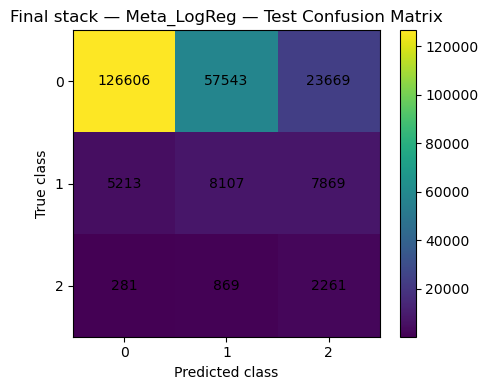

,model,importance
0,LightGBM,0.798327
1,CatBoost,0.482153
2,LogReg,0.252228



Saved:
- ../models/stacking_3model_cv_summary.csv
- ../models/stacking_3model_final_results.csv
- ../models/stacking_3model_meta_importance.csv
- ../models/stacking_3model_meta_compare.csv
- ../models/stacking_3model_dashboard_features.csv
- ../models/stacking_3model_dashboard_bundle.pkl
- ../models/stacking_3model_manifest.json


In [7]:

# ------------------------------------------------------------
# Refit base learners on all development data, score final test, save outputs
# ------------------------------------------------------------
final_models = {}
test_meta_parts = []
final_rows = []

for model_name, builder in base_model_builders.items():
    print(f"Refitting {model_name} on full development data...")

    if model_name == "CatBoost":
        model = builder(y_dev)
        model.fit(X_dev, y_dev, cat_features=cat_cols)
        proba_test = model.predict_proba(X_test)
    else:
        model = builder()
        model.fit(X_dev, y_dev)
        proba_test = model.predict_proba(X_test)

    final_models[model_name] = model
    pred_test = np.asarray(proba_test).argmax(axis=1)

    # Save each base learner's final test metrics.
    final_rows.append(
        eval_multiclass(y_test, pred_test, proba_test, name=model_name, split="test")
    )
    test_meta_parts.append(np.asarray(proba_test))

X_meta_test = np.hstack(test_meta_parts)
proba_stack_test = meta_model.predict_proba(X_meta_test)
pred_stack_test = np.asarray(proba_stack_test).argmax(axis=1)

final_rows.append(
    eval_multiclass(
        y_test,
        pred_stack_test,
        proba_stack_test,
        name=f"Stacking_{best_meta_name}",
        split="test",
    )
)

final_results = (
    pd.DataFrame(final_rows)
    .sort_values(["macro_recall", "ap_class2", "prob_rmse_macro"], ascending=[False, False, True])
    .reset_index(drop=True)
)
display(final_results)

cm_stack = confusion_matrix(y_test, pred_stack_test, labels=[0, 1, 2])
plot_confusion(cm_stack, title=f"Final stack — {best_meta_name} — Test Confusion Matrix")

# Meta importance:
# - Logistic meta learner: coefficient-based summary across probability features.
# - HistGB meta learner: permutation importance on the compact meta-feature matrix.
if hasattr(meta_model, "coef_"):
    coef_abs = np.abs(meta_model.coef_).mean(axis=0)
    meta_importance = (
        pd.DataFrame({"meta_feature": meta_feature_names, "importance": coef_abs})
        .assign(model=lambda d: d["meta_feature"].str.replace(r"_p[0-2]$", "", regex=True))
        .groupby("model", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
else:
    perm = permutation_importance(
        meta_model,
        X_meta_train,
        y_meta_train,
        n_repeats=10,
        random_state=RANDOM_SEED,
        scoring="recall_macro",
    )
    meta_importance = (
        pd.DataFrame({"meta_feature": meta_feature_names, "importance": perm.importances_mean})
        .assign(model=lambda d: d["meta_feature"].str.replace(r"_p[0-2]$", "", regex=True))
        .groupby("model", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

display(meta_importance)

# ------------------------------------------------------------
# Save compact, GitHub-clean outputs only
# ------------------------------------------------------------
cv_summary_to_save = cv_summary.copy()
cv_summary_to_save.to_csv(OUT_CV_SUMMARY, index=False)

final_summary = final_results[
    [c for c in [
        "model",
        "split",
        "macro_recall",
        "recall_2",
        "precision_2",
        "ap_class2",
        "macro_map",
        "prob_rmse_macro",
    ] if c in final_results.columns]
].copy()
final_summary.to_csv(OUT_FINAL_RESULTS, index=False)

meta_importance.to_csv(OUT_META_IMPORTANCE, index=False)
meta_compare_df.to_csv(OUT_META_COMPARE, index=False)

# Dashboard feature spec helps you build Streamlit input widgets safely.
feature_spec = pd.DataFrame({
    "feature": list(X_dev.columns),
    "type": ["categorical" if c in cat_cols else "numeric" for c in X_dev.columns],
    "example_value": [X_dev[c].iloc[0] if len(X_dev) else "" for c in X_dev.columns],
})
feature_spec.to_csv(OUT_DASHBOARD_FEATURES, index=False)

# Save one compact bundle for dashboard inference.
dashboard_bundle = {
    "model_family": "stacking_3model",
    "forecast_horizon": "next_3h_block",
    "feature_columns": list(X_dev.columns),
    "categorical_features": list(cat_cols),
    "numeric_features": list(num_cols),
    "base_model_order": list(final_models.keys()),
    "base_models": final_models,
    "meta_model": meta_model,
    "winning_meta_model_name": best_meta_name,
    "meta_compare_table": meta_compare_df,
    "class_labels": [0, 1, 2],
}
joblib.dump(dashboard_bundle, OUT_DASHBOARD_BUNDLE)

manifest = {
    "cv_summary": str(OUT_CV_SUMMARY),
    "final_summary": str(OUT_FINAL_RESULTS),
    "meta_importance": str(OUT_META_IMPORTANCE),
    "meta_compare": str(OUT_META_COMPARE),
    "dashboard_bundle": str(OUT_DASHBOARD_BUNDLE),
    "dashboard_features": str(OUT_DASHBOARD_FEATURES),
}
with open(OUT_MANIFEST, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved:")
print("-", OUT_CV_SUMMARY)
print("-", OUT_FINAL_RESULTS)
print("-", OUT_META_IMPORTANCE)
print("-", OUT_META_COMPARE)
print("-", OUT_DASHBOARD_FEATURES)
print("-", OUT_DASHBOARD_BUNDLE)
print("-", OUT_MANIFEST)
